                      DATASET OVERVIEW                      
Shape            : (150, 5)
Feature names    : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names     : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
------------------------------------------------------------
Class distribution:
species
setosa        50
versicolor    50
virginica     50

                      K TUNING RESULTS                      
K = 1   | Error Rate = 0.100
K = 2   | Error Rate = 0.133
K = 3   | Error Rate = 0.133
K = 4   | Error Rate = 0.100
K = 5   | Error Rate = 0.133
K = 6   | Error Rate = 0.133
K = 7   | Error Rate = 0.067  <-- best
K = 8   | Error Rate = 0.067
K = 9   | Error Rate = 0.100
K = 10  | Error Rate = 0.100
K = 11  | Error Rate = 0.100
K = 12  | Error Rate = 0.100
K = 13  | Error Rate = 0.133
K = 14  | Error Rate = 0.100
K = 15  | Error Rate = 0.133
K = 16  | Error Rate = 0.133
K = 17  | Error Rate = 0.133
K = 18  | Error Rate

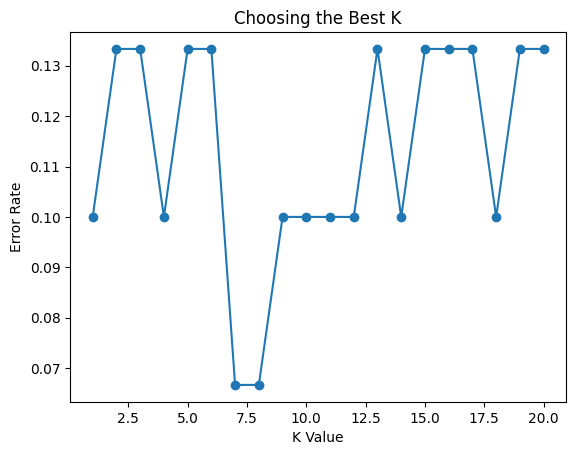

                   FINAL MODEL EVALUATION                   
Best K           : 7
Accuracy         : 93.33%
F1 Score (macro) : 0.9410
------------------------------------------------------------
Confusion Matrix:
                  setosa  versicol  virginic
setosa                 7         0         0
versicolor             0        12         0
virginica              0         2         9
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.86      1.00      0.92        12
   virginica       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.95      0.94      0.94        30
weighted avg       0.94      0.93      0.93        30



In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

print("="*60)
print("DATASET OVERVIEW".center(60))
print("="*60)
print(f"Shape            : {df.shape}")
print(f"Feature names    : {iris.feature_names}")
print(f"Target names     : {list(iris.target_names)}")
print("-"*60)
print("Class distribution:")
print(df['species'].value_counts().rename(index=dict(enumerate(iris.target_names))).to_string())
print("="*60 + "\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

error_rates = []
k_range = range(1, 21)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, pred))

best_k = k_range[error_rates.index(min(error_rates))]

print("="*60)
print("K TUNING RESULTS".center(60))
print("="*60)
for k, err in zip(k_range, error_rates):
    marker = "  <-- best" if k == best_k else ""
    print(f"K = {k:<3} | Error Rate = {err:.3f}{marker}")
print("="*60 + "\n")

plt.plot(k_range, error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Choosing the Best K')
plt.show()

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print("="*60)
print("FINAL MODEL EVALUATION".center(60))
print("="*60)
print(f"Best K           : {best_k}")
print(f"Accuracy         : {accuracy_score(y_test, predictions):.2%}")
print(f"F1 Score (macro) : {f1_score(y_test, predictions, average='macro'):.4f}")
print("-"*60)
print("Confusion Matrix:")
cm = confusion_matrix(y_test, predictions)
header = " " * 14 + "".join(f"{name[:8]:>10}" for name in iris.target_names)
print(header)
for i, row in enumerate(cm):
    print(f"{iris.target_names[i][:12]:<14}" + "".join(f"{val:>10}" for val in row))
print("-"*60)
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))
print("="*60)